# Дизайн и проверка A/B-теста

В исходных данных Online Retail II нет настоящего A/B-теста.

Я буду использовать исторические данные, чтобы спроектировать будущий эксперимент:

- выбрать гипотезу
- выбрать основную метрику
- выбрать вспомогательные и guardrail метрики
- корректно обработать AOV как ratio-метрику + применить CUPED
- провести A/A-симуляцию
- проверить результат через t-тест и bootstrap

# Фиксить графики и результаты ноутбука!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!

# !!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!


In [265]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import norm

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

## 2. Загрузка данных

Берём сохраненный аггрегат заказов из продуктового ноутбука.

Для A/B-теста нужна единица рандомизации. В этом проекте логичнее рандомизировать пользователей.

Но целевая метрика AOV - метрика отношения.

Поэтому на уровне пользователя я буду хранить только числитель и знаменатель для AOV: revenue и orders.

In [266]:
orders = pd.read_csv('../data/aggregates/orders.csv', parse_dates=['InvoiceDate', 'InvoiceDateOnly', 'InvoiceMonth'])

orders.head()

,Invoice,CustomerID,Country,InvoiceDate,IsReturn,IsSale,GrossRevenue,RefundAmount,NetRevenue,UniqueProducts,ItemsSold,ItemsReturned,InvoiceDateOnly,InvoiceMonth
0,489434,13085.0,United Kingdom,2009-12-01 07:45:00,False,True,505.30,0.0,505.30,8,166.0,NaN,2009-12-01,2009-12-01
1,489435,13085.0,United Kingdom,2009-12-01 07:46:00,False,True,145.80,0.0,145.80,4,60.0,NaN,2009-12-01,2009-12-01
2,489436,13078.0,United Kingdom,2009-12-01 09:06:00,False,True,630.33,0.0,630.33,19,193.0,NaN,2009-12-01,2009-12-01
3,489437,15362.0,United Kingdom,2009-12-01 09:08:00,False,True,310.75,0.0,310.75,23,145.0,NaN,2009-12-01,2009-12-01
4,489438,18102.0,United Kingdom,2009-12-01 09:24:00,False,True,2286.24,0.0,2286.24,17,826.0,NaN,2009-12-01,2009-12-01


In [267]:
sales_orders = orders[(orders['IsSale']) & (orders['CustomerID'].notna())].copy()
return_orders = orders[(orders['IsReturn']) & (orders['CustomerID'].notna())].copy()

sales_orders['CustomerID'] = sales_orders['CustomerID'].astype(int)
return_orders['CustomerID'] = return_orders['CustomerID'].astype(int)

## 3. Гипотеза эксперимента

Гипотеза:

- Если добавить на экран корзины блок с рекомендациями дополнительных товаров, то пользователи будут добавлять больше товаров в заказ, и средний чек вырастет.

Вариант A — обычный экран корзины.

Вариант B — экран корзины с блоком рекомендаций.

Основная метрика:

- AOV = GrossRevenue / SalesOrders

Дополнительные метрики:

- Revenue per Customer
- Orders per Customer
- Items per Order

Guardrail-метрика:

- Return Orders Rate = ReturnOrders / SalesOrders

## 4. Baseline-период

Последний месяц в датасете неполный. Я беру в качестве исторических данных (бейзлайна) год до последнего месяца, по ним оценивается размер выборки и MDE.

На данных еще за год до исторических (pre-baseline) я считаю ковариату (исторический линеаризованный AOV) для расчета линеаризованного CUPED AOV в бейзлайне.

In [268]:
last_month = sales_orders['InvoiceMonth'].drop_duplicates().sort_values().iloc[-1]
start_month = last_month - pd.DateOffset(years=1)

baseline_sales = sales_orders[
    (sales_orders['InvoiceMonth'] >= start_month) &
    (sales_orders['InvoiceMonth'] < last_month)
].copy()

baseline_returns = return_orders[
    (return_orders['InvoiceMonth'] >= start_month) &
    (return_orders['InvoiceMonth'] < last_month)
].copy()

print('Период бейзлайна:', start_month.date(), '-', last_month.date())
print('Заказы:', baseline_sales['Invoice'].nunique())
print('Клиенты:', baseline_sales['CustomerID'].nunique())

Период бейзлайна: 2010-12-01 - 2011-12-01
Заказы: 17626
Клиенты: 4293


## 5. Таблица пользователей для эксперимента

Пользовательская таблица нужна для того, чтобы у каждой единицы рандомизации были числитель и знаменатель ratio-метрики.

In [269]:
customer_data = baseline_sales.groupby('CustomerID').agg(
    revenue=('GrossRevenue', 'sum'),
    orders=('Invoice', 'nunique'),
    items=('ItemsSold', 'sum')
).reset_index()

customer_baseline_refunds = baseline_returns.groupby('CustomerID').agg(
    return_orders=('Invoice', 'nunique')
).reset_index()

customer_data = customer_data.merge(customer_baseline_refunds, on='CustomerID', how='left')
customer_data['return_orders'] = customer_data['return_orders'].fillna(0)

customer_data.head()

,CustomerID,revenue,orders,items,return_orders
0,12346,77183.60,1,74215.0,1.0
1,12347,4796.97,6,2585.0,0.0
2,12348,1437.24,4,2332.0,0.0
3,12349,1457.55,1,630.0,0.0
4,12350,294.40,1,196.0,0.0


In [270]:
aov = customer_data['revenue'].sum() / customer_data['orders'].sum()
print('AOV из таблицы пользователей:', aov)

AOV из таблицы пользователей: 485.49642403267904


## 6. Линеаризация AOV

Для каждого пользователя считаем:

linearized_aov = revenue - R * orders

In [271]:
r = aov
customer_data['linearized_aov'] = customer_data['revenue'] - r * customer_data['orders']

customer_data['linearized_aov'].describe()

count    4.293000e+03
mean    -2.169398e-13
std      7.167861e+03
min     -6.243578e+04
25%     -7.558593e+02
50%     -3.341964e+02
75%     -8.018642e+01
max      2.483331e+05
Name: linearized_aov, dtype: float64

## 7. CUPED для линеаризованной AOV

Ковариата — историческое значение той же метрики за предыдущий 12-месячный период.

In [272]:
pre_period_start = start_month - pd.DateOffset(years=1)

historical_sales = sales_orders[
    (sales_orders['InvoiceMonth'] >= pre_period_start) &
    (sales_orders['InvoiceMonth'] < start_month)
].copy()

historical_customer_data = historical_sales.groupby('CustomerID').agg(
    historical_revenue=('GrossRevenue', 'sum'),
    historical_orders=('Invoice', 'nunique')
).reset_index()

customer_data = customer_data.merge(historical_customer_data, on='CustomerID', how='left')
customer_data[['historical_revenue', 'historical_orders']] = customer_data[
    ['historical_revenue', 'historical_orders']
].fillna(0)

customer_data['historical_linearized_aov'] = (
    customer_data['historical_revenue'] - r * customer_data['historical_orders']
)

x = customer_data['historical_linearized_aov']
y = customer_data['linearized_aov']

theta = np.cov(y, x, ddof=1)[0, 1] / np.var(x, ddof=1)
customer_data['cuped_linearized_aov'] = y - theta * (x - x.mean())

variance_before_cuped = customer_data['linearized_aov'].var(ddof=1)
variance_after_cuped = customer_data['cuped_linearized_aov'].var(ddof=1)
variance_reduction = 1 - variance_after_cuped / variance_before_cuped

print('Период исторической ковариаты:', pre_period_start.date(), '-', start_month.date())
print(f'Дисперсия до CUPED: {variance_before_cuped:.2f}')
print(f'Дисперсия после CUPED: {variance_after_cuped:.2f}')
print(f'Снижение дисперсии на: {variance_reduction:.2%}')

Период исторической ковариаты: 2009-12-01 - 2010-12-01
Дисперсия до CUPED: 51378234.85
Дисперсия после CUPED: 13649409.45
Снижение дисперсии на: 73.43%


## 8. Расчёт размера выборки

Считаем размер выборки для нескольких MDE.

Так как тестируем AOV через линеаризованную метрику, MDE в AOV нужно перевести в MDE линеаризованной метрики.

MDE = MDE / числитель ratio-метрики * 100%

In [273]:
alpha = 0.05
power = 0.8

z_alpha = norm.ppf(1 - alpha / 2)
z_beta = norm.ppf(power)

sigma = customer_data['cuped_linearized_aov'].std(ddof=1)
avg_orders_per_customer = customer_data['orders'].mean()
monthly_customers = baseline_sales.groupby('InvoiceMonth')['CustomerID'].nunique().mean()
avg_numerator = customer_data['revenue'].mean()

sample_size_rows = []

for mde in [x for x in range(500, 1500, 50)]:
    n = ((z_alpha + z_beta)**2 * 2 * sigma**2) / mde**2

    total_customers = n * 2

    duration_months = total_customers / monthly_customers

    mde_percent = mde / avg_numerator

    sample_size_rows.append({
        'mde': mde,
        'mde_percent': f'{mde_percent:.2%}',
        'n': int(n),
        'total_customers': int(total_customers),
        'duration_months': round(duration_months, 3)
    })

sample_size = pd.DataFrame(sample_size_rows)

print('Среднее кол-во клиентов за месяц:', int(monthly_customers))
sample_size

Среднее кол-во клиентов за месяц: 1034


,mde,mde_percent,n,total_customers,duration_months
0,500,25.08%,857,1714,1.658
1,550,27.59%,708,1416,1.370
2,600,30.10%,595,1190,1.151
3,650,32.61%,507,1014,0.981
4,700,35.12%,437,874,0.846
5,750,37.63%,380,761,0.737
6,800,40.13%,334,669,0.648
7,850,42.64%,296,593,0.574
8,900,45.15%,264,529,0.512
9,950,47.66%,237,474,0.459


Тест получился не очень чувствительным. Примерно за месяц эксперимента собирается около 1000 пользователей, при таком размере выборки мы можем контролировать уровень ошибки II рода только при размере эффекта больше 32-35%, что очень много.

## 9. A/A-симуляция

Проверим, что выбранный статистический подход не создаёт слишком много ложных срабатываний.

В A/A-тесте настоящего эффекта нет, поэтому доля p-value меньше 0.05 должна быть около 5% и оно должно быть распределено равномерно.

In [274]:
np.random.seed(42)

p_values = []
aov_diffs = []

for _ in range(10000):
    sample = customer_data[[
        'CustomerID',
        'revenue',
        'orders',
        'historical_linearized_aov'
    ]].copy()
    sample['group'] = np.where(np.random.rand(len(sample)) < 0.5, 'A', 'B')

    control = sample[sample['group'] == 'A']
    test = sample[sample['group'] == 'B']

    r_control = control['revenue'].sum() / control['orders'].sum()
    sample['linearized_aov'] = sample['revenue'] - r_control * sample['orders']
    sample['cuped_linearized_aov'] = (
        sample['linearized_aov'] -
        theta * (sample['historical_linearized_aov'] - sample['historical_linearized_aov'].mean())
    )

    control = sample[sample['group'] == 'A']
    test = sample[sample['group'] == 'B']

    p_value = stats.ttest_ind(
        control['cuped_linearized_aov'],
        test['cuped_linearized_aov'],
    ).pvalue

    aov_a = control['revenue'].sum() / control['orders'].sum()
    aov_b = test['revenue'].sum() / test['orders'].sum()

    p_values.append(p_value)
    aov_diffs.append(aov_b / aov_a - 1)

true_alpha = (np.array(p_values) < alpha).mean()
print('True alpha:', true_alpha)

True alpha: 0.0489


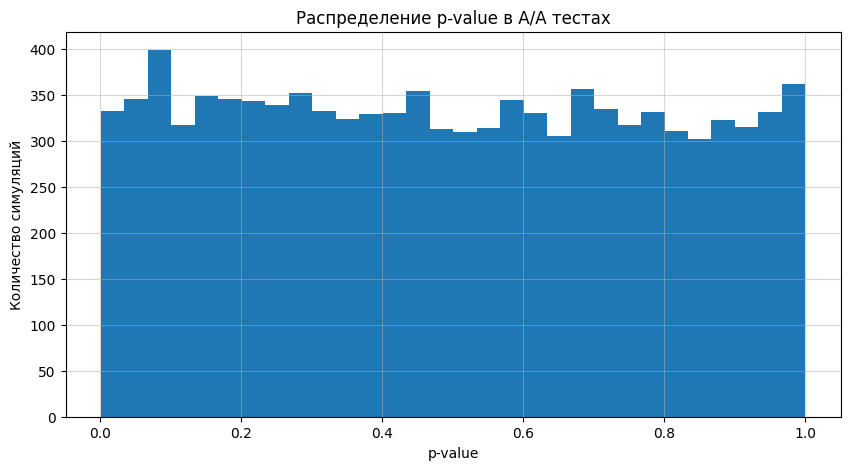

In [275]:
plt.figure(figsize=(10, 5))
plt.hist(p_values, bins=30)
plt.xlabel('p-value')
plt.ylabel('Количество симуляций')
plt.title('Распределение p-value в A/A тестах')
plt.grid(alpha=0.5)

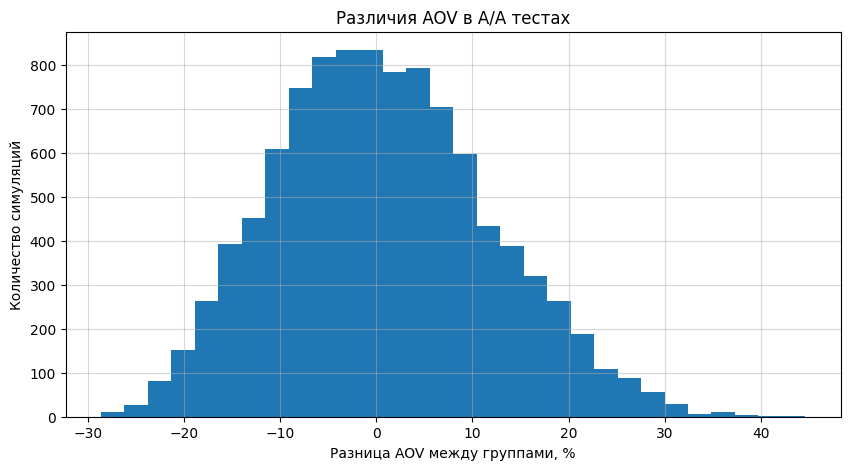

In [276]:
plt.figure(figsize=(10, 5))
plt.hist(np.array(aov_diffs) * 100, bins=30)
plt.xlabel('Разница AOV между группами, %')
plt.ylabel('Количество симуляций')
plt.title('Различия AOV в A/A тестах')
plt.grid(alpha=0.5)

## 10. Симуляция A/B теста

Теперь покажем, как выглядела бы проверка результата, если бы эксперимент уже был проведён.

Так как реальных групп в данных нет, я искусственно делю клиентов на A/B и добавляю группе B прирост в revenue.

In [277]:
np.random.seed(42)

ab_data = customer_data[[
    'CustomerID',
    'revenue',
    'orders',
    'items',
    'return_orders',
    'historical_linearized_aov'
]].copy().sample(int(monthly_customers))
ab_data['group'] = np.where(np.random.rand(len(ab_data)) < 0.5, 'A', 'B')

simulated_uplift = 0.15
ab_data.loc[ab_data['group'] == 'B', 'revenue'] = ab_data.loc[ab_data['group'] == 'B', 'revenue'] * (1 + simulated_uplift)

ab_data.head()

,CustomerID,revenue,orders,items,return_orders,historical_linearized_aov,group
3530,17228,2601.3460,8,1743.0,0.0,-1512.282120,B
2894,16340,631.4305,1,501.0,0.0,5.997152,B
3119,16654,952.9705,4,345.0,1.0,-1059.185696,B
3864,17686,5876.6035,6,2183.0,0.0,1586.357152,B
3693,17455,151.4550,1,66.0,0.0,0.000000,B


In [278]:
ab_metrics = ab_data.groupby('group').agg(
    customers=('CustomerID', 'nunique'),
    revenue=('revenue', 'sum'),
    orders=('orders', 'sum'),
    items=('items', 'sum'),
    return_orders=('return_orders', 'sum')
).reset_index()

ab_metrics['aov'] = ab_metrics['revenue'] / ab_metrics['orders']
ab_metrics['revenue_per_customer'] = ab_metrics['revenue'] / ab_metrics['customers']
ab_metrics['orders_per_customer'] = ab_metrics['orders'] / ab_metrics['customers']
ab_metrics['items_per_order'] = ab_metrics['items'] / ab_metrics['orders']
ab_metrics['return_orders_rate'] = ab_metrics['return_orders'] / ab_metrics['orders']

ab_metrics

,group,customers,revenue,orders,items,return_orders,aov,revenue_per_customer,orders_per_customer,items_per_order,return_orders_rate
0,A,506,1026323.810,2336,600520.0,453.0,439.350946,2028.307925,4.616601,257.071918,0.193921
1,B,528,963791.471,1969,482610.0,378.0,489.482718,1825.362634,3.729167,245.104114,0.191976


In [279]:
aov_a = ab_metrics[ab_metrics['group'] == 'A']['aov'].iloc[0]
aov_b = ab_metrics[ab_metrics['group'] == 'B']['aov'].iloc[0]
observed_uplift = aov_b / aov_a - 1

print(f'AOV A: {aov_a:.2f}')
print(f'AOV B: {aov_b:.2f}')
print(f'Наблюдаемый прирост: {observed_uplift:.2%}')

AOV A: 439.35
AOV B: 489.48
Наблюдаемый прирост: 11.41%


### 10.1. t-тест (линеаризация + CUPED)

Сначала считаю линеаризованную AOV, затем применяю CUPED с исторической линеаризованной AOV в качестве ковариаты.

In [280]:
control = ab_data[ab_data['group'] == 'A'].copy()
test = ab_data[ab_data['group'] == 'B'].copy()

k_control = control['revenue'].sum() / control['orders'].sum()

ab_data['linearized_aov'] = ab_data['revenue'] - k_control * ab_data['orders']

ab_data['cuped_linearized_aov'] = (
    ab_data['linearized_aov'] -
    theta * (ab_data['historical_linearized_aov'] - ab_data['historical_linearized_aov'].mean())
)

control = ab_data[ab_data['group'] == 'A']
test = ab_data[ab_data['group'] == 'B']

cuped_test_result = stats.ttest_ind(
    control['cuped_linearized_aov'],
    test['cuped_linearized_aov'],
    equal_var=False
)

print('p-value:', cuped_test_result.pvalue)

p-value: 0.005675394181164495


### 10.2. Bootstrap для AOV

Это удобный способ получить доверительный интервал для прироста ratio-метрики.

In [281]:
np.random.seed(42)

boot_uplifts = []

for _ in range(30000):
    sample_a = control.sample(len(control), replace=True)
    sample_b = test.sample(len(test), replace=True)

    boot_aov_a = sample_a['revenue'].sum() / sample_a['orders'].sum()
    boot_aov_b = sample_b['revenue'].sum() / sample_b['orders'].sum()

    boot_uplifts.append(boot_aov_b / boot_aov_a - 1)

ci = np.percentile(boot_uplifts, [2.5, 97.5])

print(f'Bootstrap uplift mean: {np.mean(boot_uplifts):.2%}')
print(f'95% CI: [{ci[0]:.2%}; {ci[1]:.2%}]')

Bootstrap uplift mean: 12.21%
95% CI: [-6.48%; 34.55%]


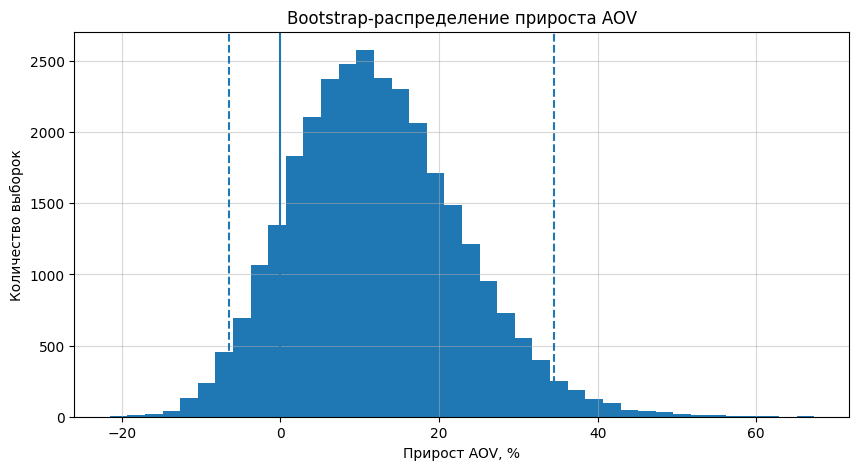

In [282]:
plt.figure(figsize=(10, 5))
plt.hist(np.array(boot_uplifts) * 100, bins=40)
plt.axvline(ci[0] * 100, linestyle='--')
plt.axvline(ci[1] * 100, linestyle='--')
plt.axvline(0, linestyle='-')
plt.xlabel('Прирост AOV, %')
plt.ylabel('Количество выборок')
plt.title('Bootstrap-распределение прироста AOV')
plt.grid(alpha=0.5)
plt.show()

### 10.3. Guardrail-метрики

Refund Rate тоже является ratio-метрикой.

In [283]:
guardrail_metrics = ab_data.groupby('group').agg(
    orders=('orders', 'sum'),
    return_orders=('return_orders', 'sum')
).reset_index()

guardrail_metrics['return_orders_rate'] = guardrail_metrics['return_orders'] / guardrail_metrics['orders']

guardrail_metrics

,group,orders,return_orders,return_orders_rate
0,A,2336,453.0,0.193921
1,B,1969,378.0,0.191976


Для синтетического A/B-теста были применены два подхода к проверке гипотезы: t-тест для CUPED линеаризованной метрики и бутстрап.

t-тест показал статистически значимый эффект, однако бутстрап не подтвердил значимость на ур.знач. 5%. В такой ситуации результат был интерпретирован консервативно: эффект не считается надежно подтверждённым, так как вывод зависит от выбранного статистического метода.

Для продуктового решения такой результат потребовал бы дополнительной проверки: увеличения выборки, продления эксперимента, анализа распределения метрики и предварительного сравнения мощности используемых тестов на синтетических A/B экспериментах.

## 15. Экспорт результатов

In [284]:
customer_data.to_csv('../data/ab/ab_customer_baseline.csv', index=False)
sample_size.to_csv('../data/ab/ab_sample_size.csv', index=False)
ab_metrics.to_csv('../data/ab/ab_simulation_metrics.csv', index=False)
ab_data.to_csv('../data/ab/ab_experiment_data.csv', index=False)

In [285]:
customer_data.head()

,CustomerID,revenue,orders,items,return_orders,linearized_aov,historical_revenue,historical_orders,historical_linearized_aov,cuped_linearized_aov
0,12346,77183.60,1,74215.0,1.0,76698.103576,169.36,2.0,-801.632848,77443.750776
1,12347,4796.97,6,2585.0,0.0,1883.991456,611.53,1.0,126.033576,1766.995866
2,12348,1437.24,4,2332.0,0.0,-504.745696,221.16,1.0,-264.336424,-258.733790
3,12349,1457.55,1,630.0,0.0,972.053576,2221.14,2.0,1250.147152,-190.262233
4,12350,294.40,1,196.0,0.0,-191.096424,0.00,0.0,0.000000,-190.892606


In [286]:
sample_size.head()

,mde,mde_percent,n,total_customers,duration_months
0,500,25.08%,857,1714,1.658
1,550,27.59%,708,1416,1.370
2,600,30.10%,595,1190,1.151
3,650,32.61%,507,1014,0.981
4,700,35.12%,437,874,0.846


In [287]:
ab_metrics

,group,customers,revenue,orders,items,return_orders,aov,revenue_per_customer,orders_per_customer,items_per_order,return_orders_rate
0,A,506,1026323.810,2336,600520.0,453.0,439.350946,2028.307925,4.616601,257.071918,0.193921
1,B,528,963791.471,1969,482610.0,378.0,489.482718,1825.362634,3.729167,245.104114,0.191976


In [288]:
ab_data.head()

,CustomerID,revenue,orders,items,return_orders,historical_linearized_aov,group,linearized_aov,cuped_linearized_aov
3530,17228,2601.3460,8,1743.0,0.0,-1512.282120,B,-913.461568,376.604947
2894,16340,631.4305,1,501.0,0.0,5.997152,B,192.079554,70.288712
3119,16654,952.9705,4,345.0,1.0,-1059.185696,B,-804.433284,64.296043
3864,17686,5876.6035,6,2183.0,0.0,1586.357152,B,3240.497824,1649.120369
3693,17455,151.4550,1,66.0,0.0,0.000000,B,-287.895946,-404.109999


## 16. Итоговые выводы

